# 1. Environment Setup
This step cleans up the workspace, clones the YOLOv10 repository, installs necessary dependencies, downloads pre-trained weights, and applies a patch for the `torch.load` Unpickling error.


In [1]:
# ==========================================
# CELL 1: ENVIRONMENT SETUP & DEPENDENCIES
# ==========================================
import os

# 1. Clean up old directory (avoid "destination path already exists" error)
!rm -rf /content/yolov10

# 2. Clone YOLOv10 repository
!git clone https://github.com/THU-MIG/yolov10.git
%cd /content/yolov10

# 3. Patch PyTorch versions in requirements to prevent dependency conflicts
!sed -i 's/torch==2.0.1/torch>=2.0.1/g' requirements.txt
!sed -i 's/torchvision==0.15.2/torchvision>=0.15.2/g' requirements.txt
!sed -i 's/torchaudio==2.0.2/torchaudio>=2.0.2/g' requirements.txt

# 4. Install required libraries
!pip install -q -r requirements.txt
!pip install -e .
!pip install -q ensemble-boxes albumentations

# 5. Download YOLOv10s pre-trained weights
!wget https://github.com/THU-MIG/yolov10/releases/download/v1.1/yolov10s.pt

# 6. Apply fix for PyTorch 'weights_only' loading error in ultralytics tasks.py
!sed -i 's/torch.load(file, map_location=\"cpu\")/torch.load(file, map_location=\"cpu\", weights_only=False)/g' /content/yolov10/ultralytics/nn/tasks.py

# 7. Import essential libraries and patch torch.load globally
import shutil
import pandas as pd
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter
from ensemble_boxes import weighted_boxes_fusion
from sklearn.model_selection import train_test_split
from ultralytics import YOLOv10

_original_load = torch.load
def _custom_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return _original_load(*args, **kwargs)
torch.load = _custom_load

print("✅ CELL 1: Environment setup completed successfully!")

Cloning into 'yolov10'...
remote: Enumerating objects: 20338, done.
remote: Total 20338 (delta 0), reused 0 (delta 0), pack-reused 20338 (from 1)
Receiving objects: 100% (20338/20338), 11.10 MiB | 18.67 MiB/s, done.
Resolving deltas: 100% (14354/14354), done.
/content/yolov10
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: Could not find a version that satisfies the requirement onnxruntime==1.15.1 (from versions: 1.20.0, 1.20.1, 1.21.0, 1.21.1, 1.22.0, 1.22.1, 1.23.0, 1.23.1, 1.23.2, 1.24.1, 1.24.2, 1.24.3, 1.24.4, 1.25.0, 1.25.1, 1.26.0, 1.27.0, 1.28.0, 1.29.0, 1.30.0)
ERROR: No matching distribution found for onnxruntime==1.15.1
Obtaining file:///content/yolov10
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproje

# 2. Data Directory Setup
Define global path constants and create the standard YOLO directory structure (`images/train`, `images/val`, `labels/train`, `labels/val`).

In [2]:
# ==========================================
# CELL 2: DEFINE PATHS & CREATE DIRECTORIES
# ==========================================

# 1. Define global paths
CSV_PATH = '/content/raw_data/images/vinbigdata/train.csv'
IMG_DIR = '/content/raw_data/images/vinbigdata/train'
BASE_DIR = '/content/vinbigdata_yolo'
NEW_BASE_DIR = '/content/vinbigdata_yolo_optimized'

# 2. Create YOLO-standard directory structure
for split in ['train', 'val']:
    os.makedirs(f'{BASE_DIR}/images/{split}', exist_ok=True)
    os.makedirs(f'{BASE_DIR}/labels/{split}', exist_ok=True)

# 3. Download dataset (Uncomment if running on a fresh Colab instance)
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download awsaf49/vinbigdata-512-image-dataset -p /content/raw_data/images/ --unzip


print("✅ CELL 2: Directory structure is ready!")

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/awsaf49/vinbigdata-512-image-dataset
License(s): unknown
100% 2.30G/2.30G [00:59<00:00, 41.7MB/s]

✅ CELL 2: Directory structure is ready!


# 3. Exploratory Data Analysis (EDA)
Analyze the bounding box distribution across disease classes (excluding class 14 - normal images) from the original CSV file to get an overview of data imbalance.

📊 DISEASE LABELS DISTRIBUTION (FROM RAW CSV):
--------------------------------------------------
Class  0 | Aortic enlargement   |   7162 boxes
Class  1 | Atelectasis          |    279 boxes
Class  2 | Calcification        |    960 boxes
Class  3 | Cardiomegaly         |   5427 boxes
Class  4 | Consolidation        |    556 boxes
Class  5 | ILD                  |   1000 boxes
Class  6 | Infiltration         |   1247 boxes
Class  7 | Lung Opacity         |   2483 boxes
Class  8 | Nodule/Mass          |   2580 boxes
Class  9 | Other lesion         |   2203 boxes
Class 10 | Pleural effusion     |   2476 boxes
Class 11 | Pleural thickening   |   4842 boxes
Class 12 | Pneumothorax         |    226 boxes
Class 13 | Pulmonary fibrosis   |   4655 boxes
--------------------------------------------------
TOTAL: 36096 bounding boxes



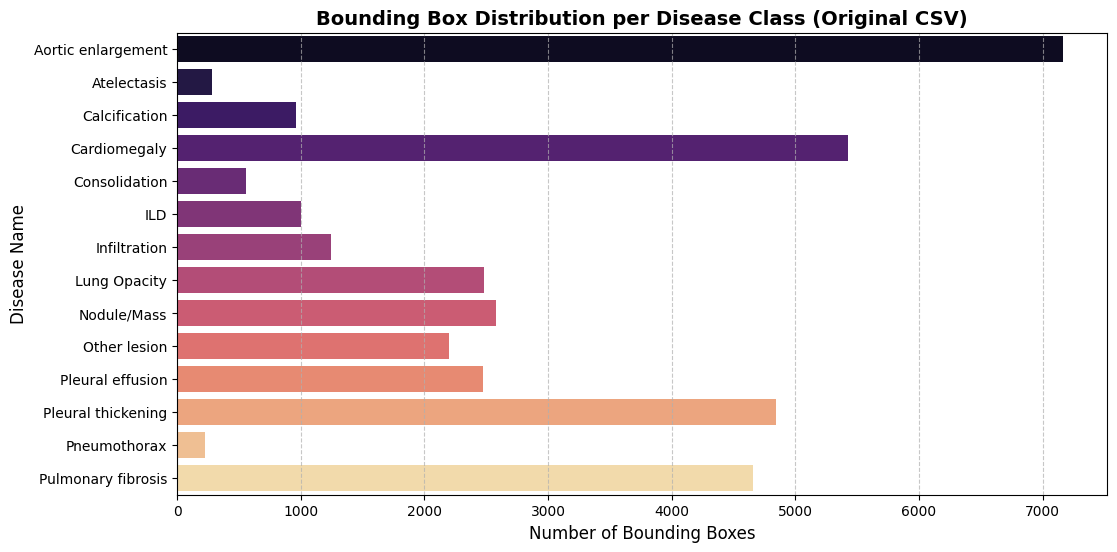

In [3]:
# ==========================================
# CELL 3: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

# 1. Read the original CSV file
df_full = pd.read_csv(CSV_PATH)

# 2. Filter out Class 14 (No finding / Normal images)
df_abnormal = df_full[df_full['class_id'] != 14]

# 3. Count bounding boxes per class (0 to 13)
class_counts = df_abnormal['class_id'].value_counts().sort_index()

class_names = [
    'Aortic enlargement', 'Atelectasis', 'Calcification', 'Cardiomegaly',
    'Consolidation', 'ILD', 'Infiltration', 'Lung Opacity', 'Nodule/Mass',
    'Other lesion', 'Pleural effusion', 'Pleural thickening', 'Pneumothorax', 'Pulmonary fibrosis'
]

print("📊 DISEASE LABELS DISTRIBUTION (FROM RAW CSV):")
print("-" * 50)
total_boxes = 0
counts_list = []
for i in range(14):
    count = class_counts.get(i, 0)
    counts_list.append(count)
    total_boxes += count
    print(f"Class {i:2d} | {class_names[i]:<20} | {count:6d} boxes")
print("-" * 50)
print(f"TOTAL: {total_boxes} bounding boxes\n")

# 4. Plot the distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=counts_list, y=class_names, hue=class_names, legend=False, palette='magma')
plt.title('Bounding Box Distribution per Disease Class (Original CSV)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Bounding Boxes', fontsize=12)
plt.ylabel('Disease Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 4. CSV Preprocessing & Background Sampling
Normalize bounding box coordinates to YOLO's `[0, 1]` scale. Randomly sample 1500 images without findings (Class 14) to use as background images, which helps reduce false positives.

In [4]:
# ==========================================
# CELL 4: CSV PREPROCESSING & BACKGROUND SAMPLING
# ==========================================

print("Reading CSV and parsing labels...")
df = pd.read_csv(CSV_PATH)

# 1. Separate disease images (Class 0-13) and normal images (Class 14)
df_disease = df[df.class_id != 14].reset_index(drop=True)
df_normal = df[df.class_id == 14].reset_index(drop=True)

# 2. Randomly sample exactly 1500 image_ids for normal (background) images
normal_image_ids = df_normal['image_id'].unique()
np.random.seed(42) # Fix seed for reproducibility
sampled_normal_ids = np.random.choice(normal_image_ids, 1500, replace=False)

# 3. Normalize coordinates (Only applied to DISEASE images)
df_disease['x_min'] = df_disease['x_min'] / df_disease['width']
df_disease['y_min'] = df_disease['y_min'] / df_disease['height']
df_disease['x_max'] = df_disease['x_max'] / df_disease['width']
df_disease['y_max'] = df_disease['y_max'] / df_disease['height']

# Ensure coordinates are within [0.0, 1.0] bounds
for col in ['x_min', 'y_min', 'x_max', 'y_max']:
    df_disease[col] = df_disease[col].clip(0.0, 1.0)

# Reassign to 'df' for the WBF algorithm in the next step
df = df_disease

print(f"✅ Sampled {len(sampled_normal_ids)} normal images for background.")
print(f"✅ Completed! Remaining {len(df)} disease labels for WBF processing.")

Reading CSV and parsing labels...
✅ Sampled 1500 normal images for background.
✅ Completed! Remaining 36096 disease labels for WBF processing.


# 5. Weighted Boxes Fusion (WBF) with Consensus Filter
Since the data is annotated by multiple radiologists, bounding boxes often overlap. The WBF algorithm, combined with a Consensus Filter, merges these overlapping boxes to generate high-quality Ground Truth labels.

In [5]:
# ==========================================
# CELL 5: WEIGHTED BOXES FUSION (WBF) WITH CONSENSUS
# ==========================================
print("Running WBF to merge overlapping labels... (This may take 1-2 minutes)")

image_ids = df['image_id'].unique()
wbf_results = []

# --- CONSENSUS THRESHOLD ---
# 0.0: Keep all boxes
# 0.4: Keep boxes agreed upon by at least 2 doctors (Recommended to boost mAP)
# 0.7: Strict mode - requires agreement from all 3 doctors
CONSENSUS_THRESHOLD = 0.4

for img_id in tqdm(image_ids):
    img_df = df[df['image_id'] == img_id]

    # Get a list of all radiologists who diagnosed this image
    rads = img_df['rad_id'].unique()
    boxes_list, scores_list, labels_list = [], [], []

    for rad in rads:
        rad_df = img_df[img_df['rad_id'] == rad]
        boxes_list.append(rad_df[['x_min', 'y_min', 'x_max', 'y_max']].values.tolist())
        labels_list.append(rad_df['class_id'].values.tolist())
        # Initial confidence score for each doctor's annotation is set to 1.0
        scores_list.append([1.0] * len(rad_df))

    # Apply Weighted Boxes Fusion (WBF)
    boxes, scores, labels = weighted_boxes_fusion(
        boxes_list, scores_list, labels_list,
        iou_thr=0.4, skip_box_thr=0.0
    )

    # Apply consensus filter based on WBF scores
    for box, score, label in zip(boxes, scores, labels):
        if score > CONSENSUS_THRESHOLD:
            wbf_results.append({
                'image_id': img_id,
                'class_id': int(label),
                'x_min': box[0], 'y_min': box[1], 'x_max': box[2], 'y_max': box[3],
                'wbf_score': score
            })

df_wbf = pd.DataFrame(wbf_results)

# Convert coordinates to YOLO format (x_center, y_center, width, height)
df_wbf['x_center'] = (df_wbf['x_min'] + df_wbf['x_max']) / 2.0
df_wbf['y_center'] = (df_wbf['y_min'] + df_wbf['y_max']) / 2.0
df_wbf['w'] = df_wbf['x_max'] - df_wbf['x_min']
df_wbf['h'] = df_wbf['y_max'] - df_wbf['y_min']

print(f"\n✅ CELL 5: WBF completed! Reduced to {len(df_wbf)} high-quality ground truth labels.")

Running WBF to merge overlapping labels... (This may take 1-2 minutes)


100%|██████████| 4394/4394 [00:41<00:00, 106.23it/s]


✅ CELL 5: WBF completed! Reduced to 8824 high-quality ground truth labels.


# 6. Train/Val Split & YOLO Format Export
Randomly split the dataset into 80% for Training and 20% for Validation. Note: Background images are also split proportionally and included in the final dataset.

In [6]:
# ==========================================
# CELL 6: TRAIN/VAL SPLIT AND YOLO FORMAT EXPORT
# ==========================================

# 1. Get unique image IDs for disease images
all_disease_imgs = df_wbf['image_id'].unique()

# 2. Random split: 80% Train, 20% Val
train_imgs, val_imgs = train_test_split(all_disease_imgs, test_size=0.2, random_state=42)

# 3. Split the 1500 background (normal) images: 1200 for Train, 300 for Val
train_normal_imgs = sampled_normal_ids[:1200]
val_normal_imgs = sampled_normal_ids[1200:]

# 4. Concatenate disease and normal images
train_imgs = np.concatenate([train_imgs, train_normal_imgs])
val_imgs = np.concatenate([val_imgs, val_normal_imgs])

def export_yolo_data(img_list, split_name):
    print(f"Copying images and generating .txt labels for {split_name} set...")
    for img_id in tqdm(img_list):
        # Fetch labels for the current image (empty for background images)
        img_labels = df_wbf[df_wbf['image_id'] == img_id]

        # Generate .txt label file (creates an empty file for background images)
        with open(f"{BASE_DIR}/labels/{split_name}/{img_id}.txt", 'w') as f:
            for _, row in img_labels.iterrows():
                f.write(f"{int(row['class_id'])} {row['x_center']:.6f} {row['y_center']:.6f} {row['w']:.6f} {row['h']:.6f}\n")

        # Copy image file
        src_img = f"{IMG_DIR}/{img_id}.png"
        dst_img = f"{BASE_DIR}/images/{split_name}/{img_id}.png"

        if os.path.exists(src_img) and not os.path.exists(dst_img):
            shutil.copy(src_img, dst_img)

export_yolo_data(train_imgs, 'train')
export_yolo_data(val_imgs, 'val')

print(f"\n✅ CELL 6: Data is 100% ready for YOLO! Background images included.")

Copying images and generating .txt labels for train set...


100%|██████████| 4591/4591 [00:09<00:00, 468.14it/s]


Copying images and generating .txt labels for val set...


100%|██████████| 1148/1148 [00:02<00:00, 516.25it/s]


✅ CELL 6: Data is 100% ready for YOLO! Background images included.


# 7. Advanced Data Augmentation & Oversampling
Utilize the Albumentations library to optimize medical images using the CLAHE algorithm. Apply **Oversampling** (injecting artificial data via rotation, scaling, and noise addition) for minority classes to mitigate class imbalance.

In [7]:
# =======================================================
# CELL 7: ADVANCED PREPROCESSING - ALBUMENTATIONS & OVERSAMPLING
# =======================================================
import albumentations as A

# 1. Initialize the optimized directory tree
for split in ['train', 'val']:
    os.makedirs(f"{NEW_BASE_DIR}/images/{split}", exist_ok=True)
    os.makedirs(f"{NEW_BASE_DIR}/labels/{split}", exist_ok=True)

# 2. Define minority classes for oversampling multipliers
GROUP_X3 = [1, 4, 12]   # Classes with < 500 boxes
GROUP_X2 = [2, 5, 6]    # Classes with 500-1000 boxes

# 3. DEFINE ALBUMENTATIONS TRANSFORM PIPELINES

# Base pipeline: Applied to all images (CLAHE for contrast enhancement)
base_transform = A.Compose([
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.1))

# Augmentation pipeline: Applied to oversampled copies (Geometric & Optical distortions)
aug_transform = A.Compose([
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0),
    # Geometric distortions (simulate minor X-ray variations)
    A.Affine(scale=(0.97, 1.03), translate_percent=(-0.05, 0.05), rotate=(-5, 5), p=0.8),
    # Optical distortions
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.6),
    A.GaussNoise(std_range=(0.1, 0.3), p=0.4), # Updated for newer Albumentations API
    # Coarse Dropout (hide small patches to prevent overfitting)
    A.CoarseDropout(num_holes_range=(1, 3), hole_height_range=(15, 40), hole_width_range=(15, 40), p=0.4)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.2))

print("Starting Albumentations processing...")

for split in ['train', 'val']:
    img_dir = f"{BASE_DIR}/images/{split}"
    lbl_dir = f"{BASE_DIR}/labels/{split}"

    if not os.path.exists(img_dir): continue
    img_files = [f for f in os.listdir(img_dir) if f.endswith(('.png', '.jpg'))]

    for filename in tqdm(img_files, desc=f"Processing {split.upper()} set"):
        base_name = os.path.splitext(filename)[0]
        img_path = os.path.join(img_dir, filename)
        lbl_path = os.path.join(lbl_dir, f"{base_name}.txt")

        # Read original image
        image = cv2.imread(img_path)
        if image is None: continue
        # Albumentations expects RGB format
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        bboxes = []
        class_labels = []
        multiplier = 1

        # Parse Bounding Boxes
        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        c_id = int(parts[0])
                        x_c, y_c, w, h = map(float, parts[1:5])

                        # Safety clip to ensure coordinates are strictly within bounds [0.001, 0.999]
                        x_c = np.clip(x_c, 0.001, 0.999)
                        y_c = np.clip(y_c, 0.001, 0.999)
                        w = np.clip(w, 0.001, min(w, x_c*2, (1-x_c)*2))
                        h = np.clip(h, 0.001, min(h, y_c*2, (1-y_c)*2))

                        bboxes.append([x_c, y_c, w, h])
                        class_labels.append(c_id)

            # Determine oversampling multiplier (Train set only)
            if split == 'train':
                if any(c in GROUP_X3 for c in class_labels): multiplier = 3
                elif any(c in GROUP_X2 for c in class_labels): multiplier = 2

        # 4. Apply transformations and save
        for i in range(multiplier):
            new_img_name = f"{base_name}.png" if i == 0 else f"{base_name}_aug{i}.png"
            new_lbl_name = f"{base_name}.txt" if i == 0 else f"{base_name}_aug{i}.txt"

            # Base version always keeps original coordinates (only CLAHE applied)
            if i == 0:
                transformed = base_transform(image=image, bboxes=bboxes, class_labels=class_labels)
            # Subsequent copies receive rotation, noise, and dropout
            else:
                transformed = aug_transform(image=image, bboxes=bboxes, class_labels=class_labels)

            # Convert back to BGR for cv2 saving
            out_image = cv2.cvtColor(transformed['image'], cv2.COLOR_RGB2BGR)
            out_bboxes = transformed['bboxes']
            out_classes = transformed['class_labels']

            # Save augmented image
            cv2.imwrite(f"{NEW_BASE_DIR}/images/{split}/{new_img_name}", out_image)

            # Save augmented labels
            if len(out_bboxes) > 0:
                with open(f"{NEW_BASE_DIR}/labels/{split}/{new_lbl_name}", 'w') as f:
                    for cls_id, box in zip(out_classes, out_bboxes):
                        f.write(f"{cls_id} {box[0]:.6f} {box[1]:.6f} {box[2]:.6f} {box[3]:.6f}\n")

# Print dataset statistics after augmentation
train_dir = f"{NEW_BASE_DIR}/images/train"
val_dir = f"{NEW_BASE_DIR}/images/val"
train_count = len([f for f in os.listdir(train_dir) if f.endswith(('.png', '.jpg'))]) if os.path.exists(train_dir) else 0
val_count = len([f for f in os.listdir(val_dir) if f.endswith(('.png', '.jpg'))]) if os.path.exists(val_dir) else 0

print("\n📊 DATASET STATISTICS AFTER OVERSAMPLING:")
print("-" * 45)
print(f"TRAIN Set (Oversampled) : {train_count} images")
print(f"VAL Set   (Unchanged)   : {val_count} images")
print("-" * 45)
print(f"TOTAL                   : {train_count + val_count} images")
print("✅ CELL 7: Data augmentation completed successfully!")

/usr/local/lib/python3.13/dist-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


Starting Albumentations processing...


Processing VAL set: 100%|██████████| 1148/1148 [00:30<00:00, 37.08it/s]


📊 DATASET STATISTICS AFTER OVERSAMPLING:
---------------------------------------------
TRAIN Set (Oversampled) : 5256 images
VAL Set   (Unchanged)   : 1148 images
---------------------------------------------
TOTAL                   : 6404 images
✅ CELL 7: Data augmentation completed successfully!


In [8]:
# ==========================================
# CELL 6: HUẤN LUYỆN MÔ HÌNH (TRAIN)
# ==========================================
# Tạo file yaml cấu hình
yaml_content = f"""
path: {NEW_BASE_DIR}
train: images/train
val: images/val
nc: 14
names: ['Aortic enlargement', 'Atelectasis', 'Calcification', 'Cardiomegaly', 'Consolidation', 'ILD', 'Infiltration', 'Lung Opacity', 'Nodule/Mass', 'Other lesion', 'Pleural effusion', 'Pleural thickening', 'Pneumothorax', 'Pulmonary fibrosis']
"""
with open(f'{NEW_BASE_DIR}/data.yaml', 'w') as f:
    f.write(yaml_content)

print("Bắt đầu huấn luyện mô hình YOLOv10l (Large)...")

Bắt đầu huấn luyện mô hình YOLOv10l (Large)...


# 8. YOLOv10 Configuration & Training
Create the `data.yaml` configuration file and initiate the training process. This includes an option to resume training from the `last.pt` checkpoint if a previous run was interrupted.

In [9]:
# ==========================================
# CELL 8: YOLOv10 CONFIGURATION & TRAINING
# ==========================================

# 1. Create the data.yaml configuration file
yaml_content = f"""
path: {NEW_BASE_DIR}
train: images/train
val: images/val
nc: 14
names: ['Aortic enlargement', 'Atelectasis', 'Calcification', 'Cardiomegaly', 'Consolidation', 'ILD', 'Infiltration', 'Lung Opacity', 'Nodule/Mass', 'Other lesion', 'Pleural effusion', 'Pleural thickening', 'Pneumothorax', 'Pulmonary fibrosis']
"""
with open(f'{NEW_BASE_DIR}/data.yaml', 'w') as f:
    f.write(yaml_content)

print("Starting YOLOv10 Large training process...")

# 2. Train the model

# model = YOLOv10('yolov10s.pt')
# results = model.train(
#     data=f'{NEW_BASE_DIR}/data.yaml',
#     epochs=100,
#     imgsz=512,
#     batch=64,
#     device=0,
#     workers=8,
#     patience=25,
#     close_mosaic=15,
#     project='VinBigData_Detection',
#     name='yolov10l_img640'
# )

print("✅ CELL 8: Training execution finished!")

Starting YOLOv10 Large training process...
✅ CELL 8: Training execution finished!
